## Ugropy power users

In this final section of the tutorial, we will explore some advanced features of
`ugropy` that were not covered in the previous sections. These features are
intended for users who want to customize the behavior of the already
implemented models in `ugropy` or who want to implement their own models.

### Non-optimal solutions

As explained in previous sections, `ugropy` allows you to search for multiple
solutions for the models, but all these solutions are optimal (they use the same
number of groups to represent the molecule). However, it is possible to search for
non-optimal solutions along with the optimal ones. This is useful when you want 
to find all possible combinations of fragments that cover the molecule.
Please note that this feature is intended for research purposes and is not 
recommended for actually modeling molecules.

We can enable this for all `ugropy` models using the `search_nonoptimal`
parameter:

In [1]:
from ugropy import unifac

solutions = unifac.get_groups(
    "9,10-dihydroanthracene",
    search_multiple_solutions=True, # If this is False, search_nonoptimal is ignored
    search_nonoptimal=True,
)

# Three solutions were found:
solutions

We can visualize all the obtained solutions:

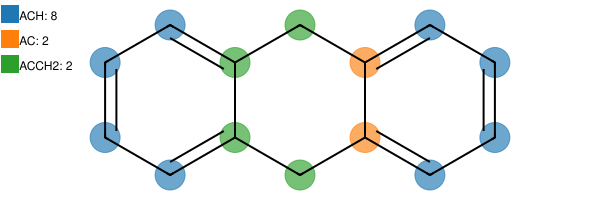

In [2]:
solutions[0].draw(width=600)

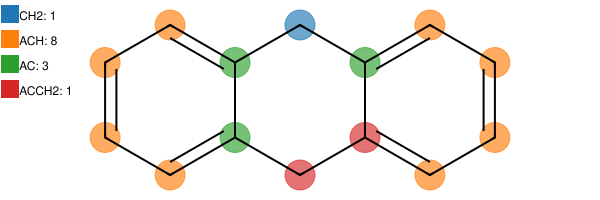

In [3]:
solutions[1].draw(width=600)

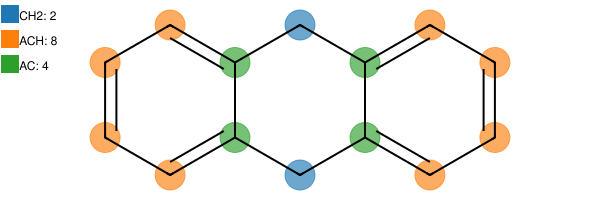

In [4]:
solutions[2].draw(width=600)

If you are an experienced user of UNIFAC-like models, you may notice that the
only "correct" solution is the first one. When non-optimal solutions are
enabled, the algorithm will always find the optimal solutions first, and then
it will search for non-optimal solutions in a "non-optimal" order.

### Changing the default ILP solver

By default, `ugropy` uses the standard CBC solver from the `PuLP` library.
However, `PuLP` supports a wide variety of solvers. Changing the ILP solver can
significantly impact the library's execution time. A great alternative is the
`XPRESS_PY` solver.

First, you must install `XPRESS`:

```shell
pip install xpress
```

Then, you can change the default solver by passing it as an argument:

/home/salvador/.virtualenvs/ugropy/lib/python3.12/site-packages/pulp/apis/xpress_api.py:751: LicenseWarning: Using the Community license in this session. If you have a full Xpress license, pass the full path to your license file to xpress.init(). If you want to use the FICO Community license and no longer want to see this message, use the following code before using the xpress module:
  xpress.init('/home/salvador/.virtualenvs/ugropy/lib/python3.12/site-packages/xpress/license/community-xpauth.xpr')
  model = xpress.problem()
/home/salvador/.virtualenvs/ugropy/lib/python3.12/site-packages/pulp/apis/xpress_api.py:774: DeprecationWarning: Deprecated in Xpress 9.8: use problem.addCols instead.
  model.addcols(obj, [0] * (len(obj) + 1), [], [], lb, ub, names, ctype)


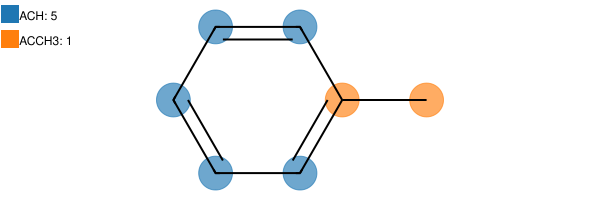

In [5]:
from ugropy import unifac


unifac.get_groups("toluene", solver_arguments={"solver": "XPRESS_PY"}).draw(width=600)

### Understanding model instances and their configuration

`ugropy` is designed using the singleton pattern; therefore, all the models we
have been using throughout this tutorial are instances of the `FragmentationModel` 
class. This class possesses several attributes that can be used to inspect 
the models' information and definitions.

Each model in `ugropy` is composed of two distinct classes:
`FragmentationModel` and `FragmentationResult`.

The `FragmentationModel` class contains all the fundamental information 
about a model, such as its fragment definitions. It serves as the base class 
required to define a minimal model and implements the `get_groups` method. 
The specific models in `ugropy` are not direct instances of this base class, 
but rather instances of subclasses that inherit from it. For example, the 
UNIFAC model is an instance of the `GibbsModel` class (a subclass of 
`FragmentationModel`). The advantage of these subclasses is that they provide 
additional methods (such as multiple-solution filtering). Furthermore, a 
`GibbsModel` requires more detailed fragment information to be instantiated, 
such as the $R$ and $Q$ parameters.

Finally, each `FragmentationModel` returns an instance of its specific 
`FragmentationResult` subclass when the `get_groups` method is called. In the 
case of a `GibbsModel`, the `get_groups` method returns a 
`GibbsFragmentationResult` instance (which inherits from `FragmentationResult`). 
This architectural design allows different models to perform specific 
post-processing tasks after fragment detection. For instance, the 
`GibbsFragmentationResult` class automatically calculates the $R$ and $Q$ values 
of the solution, while the `JobackFragmentationResult` class computes the 
Joback group-contribution properties.

Understanding this architecture is important because it guarantees that while 
all models share the core attributes and methods required by the 
`FragmentationModel` base class, they also offer specialized features 
depending on their specific subclass.

Let's examine the documentation of a base `FragmentationModel` class (you can 
always check the API documentation for the complete list of methods and attributes).

In [6]:
from ugropy import FragmentationModel

help(FragmentationModel)

Help on class FragmentationModel in module ugropy.core.frag_classes.base.fragmentation_model:

class FragmentationModel(builtins.object)
 |  FragmentationModel(subgroups: pandas.DataFrame, allow_overlapping: bool = False, allow_free_atoms: bool = False, fragmentation_result: ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult = <class 'ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult'>) -> None
 |
 |  FragmentationModel class.
 |
 |  All ugropy supported models are an instance of this class. This class must
 |  be inherited to create a new type of FragmentationModel.
 |
 |  Parameters
 |  ----------
 |  subgroups : pd.DataFrame
 |      Model's subgroups. Index: 'group' (subgroups names). Mandatory columns:
 |      'smarts' (SMARTS representations of the group to detect its presense in
 |      the molecule).
 |  allow_overlapping : bool, optional
 |      Whether allow overlapping or not, by default False
 |  allow_free_atoms : bool, optional
 |  

You can instantiate a base `FragmentationModel` class with the minimum
required information.

This class expects a pandas DataFrame (`subgroups` parameter) that contains a 
specific index and a mandatory column. The index, named `group`, contains the 
names of the fragments, and the column, named `smarts`, contains the SMARTS 
patterns of the fragments. 

The class also accepts a boolean parameter called `allow_overlapping`, which 
indicates whether the model allows the detected fragments within the molecule 
to overlap. Similarly, the `allow_free_atoms` argument indicates whether the 
model allows free atoms (atoms not occupied by any group). Finally, it requires 
a `FragmentationResult` class; by default, the base `FragmentationResult` 
class is used.

In the "Getting Started - About the Algorithm" section of the tutorial, we
defined some models by identifying the fragments directly with the RDKit library. 
Now, let's achieve the same result using the `FragmentationModel` class.

The fragments that we previously defined were:

```python
# Definition of the fragments of our model

# Aliphatic CH2
ch2 = Chem.MolFromSmarts("[CX4H2]")

# Aromatic CH
ach = Chem.MolFromSmarts("[cH]")

# Aromatic C without H
ac = Chem.MolFromSmarts("[cH0]")

# Aromatic C bonded with aliphatic CH2
acch2 = Chem.MolFromSmarts("[cH0][CX4H2]")

# List of fragments of our model
fragments = [ch2, ach, ac, acch2]
fragments_names = ["CH2", "ACH", "AC", "ACCH2"]
```

Let's build a DataFrame with this information (later, you can store it as a
.csv file and load it with pandas to reinstantiate the model):

In [7]:
import pandas as pd

from ugropy import FragmentationModel, FragmentationResult


subgroups = pd.DataFrame(
    {
        "group": ["CH2", "ACH", "AC", "ACCH2"],
        "smarts": ["[CX4H2]", "[cH]", "[cH0]", "[cH0][CX4H2]"],
    },
)

subgroups.set_index("group", inplace=True)

subgroups

,smarts
group,
CH2,[CX4H2]
ACH,[cH]
AC,[cH0]
ACCH2,[cH0][CX4H2]


Now, let's instantiate our model:

In [8]:
our_model = FragmentationModel(
    subgroups=subgroups,
    allow_overlapping=False,
    allow_free_atoms=False,
    fragmentation_result=FragmentationResult
)

We can use this model to fragment a molecule in the same way we used the other
`ugropy` models. The result will be a FragmentationResult instance (you can
check the API documentation for more details on this class). Let's test it with
the same molecule we used in the "About the Algorithm" section of the tutorial.

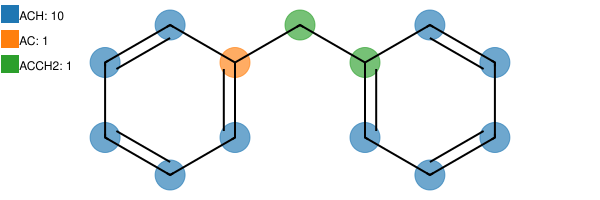

In [9]:
result = our_model.get_groups("c1ccccc1Cc2ccccc2", "smiles")

result.draw(width=600)

This returns the result as a dictionary of group occurrences, using the names 
we defined in our DataFrame as keys:

In [10]:
result.subgroups

{'ACH': 10, 'AC': 1, 'ACCH2': 1}

The specific molecule atoms covered by each fragment can be accessed via the 
`subgroups_atoms` attribute of the `FragmentationResult` instance. This 
attribute is a dictionary where the keys are the fragment names, and the values 
are lists of lists containing the atom indices covered by each occurrence. 
Consequently, the number of nested lists matches the total occurrences of 
that fragment in the molecule.

In [11]:
result.subgroups_atoms

{'ACH': [(0,), (1,), (2,), (3,), (4,), (8,), (9,), (10,), (11,), (12,)],
 'AC': [(5,)],
 'ACCH2': [(7, 6)]}

In [12]:
type(result)

ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult

Since we did not allow overlapping in the previous example, the algorithm found
the optimal solution, ensuring that each atom of the molecule was covered by
only one fragment (while using the minimum number of groups).

Let's see what happens if we allow overlapping:

In [13]:
our_model_olap = FragmentationModel(
    subgroups=subgroups,
    allow_overlapping=True,
    allow_free_atoms=False,
    fragmentation_result=FragmentationResult
)

result_overlapping = our_model_olap.get_groups("c1ccccc1Cc2ccccc2", "smiles")

print(result_overlapping.subgroups)
print(result_overlapping.subgroups_atoms)

{'CH2': 1, 'ACH': 10, 'AC': 2, 'ACCH2': 2}
{'CH2': [(6,)], 'ACH': [(0,), (1,), (2,), (3,), (4,), (8,), (9,), (10,), (11,), (12,)], 'AC': [(5,), (7,)], 'ACCH2': [(5, 6), (7, 6)]}


As you can see, because overlapping was enabled, the algorithm directly
returned all detected fragments in the molecule without searching for an
optimal partition. Consequently, some atoms are now covered by multiple
fragments.

Let's inspect the internal attributes of our `our_model` instance. First, we
can access the same parameters we specified during instantiation. Since these
are attributes of the base class, they are available across all models in
`ugropy`.

In [14]:
print("Fragments of the model:")
print(our_model.subgroups)
print("Allow overlapping:", our_model.allow_overlapping)
print("Allow free atoms:", our_model.allow_free_atoms)
print("Fragmentation result class:", our_model.fragmentation_result)

Fragments of the model:
             smarts
group              
CH2         [CX4H2]
ACH            [cH]
AC            [cH0]
ACCH2  [cH0][CX4H2]
Allow overlapping: False
Allow free atoms: False
Fragmentation result class: <class 'ugropy.core.frag_classes.base.fragmentation_result.FragmentationResult'>


We have an additional, and important, attribute called `detection_mols`:

In [15]:
our_model.detection_mols

{'CH2': <rdkit.Chem.rdchem.Mol at 0x7f6305b12ab0>,
 'ACH': <rdkit.Chem.rdchem.Mol at 0x7f6305b12b20>,
 'AC': <rdkit.Chem.rdchem.Mol at 0x7f6305b13f40>,
 'ACCH2': <rdkit.Chem.rdchem.Mol at 0x7f6305b13450>}

When you instantiate a model, during initialization, all the fragments defined
in the DataFrame are used to create a dictionary. This dictionary contains the
fragment names as keys, and the corresponding RDKit Mol objects as values,
which are created internally as:

```python
from rdkit import Chem

mol = Chem.MolFromSmarts(smarts)
```

For this reason, all the SMARTS patterns we define must be compatible with the
`RDKit` library. This attribute is used internally by the `get_groups` method
to search for fragments within the molecule. Pre-building these objects avoids
recreating the `RDKit` `Mol` instances every time `get_groups` is called,
significantly optimizing execution time.

As mentioned before, these are the attributes common to any
`FragmentationModel` subclass, but specific subclasses can implement additional
attributes. For example, an instance of the `GibbsModel` class possesses all
the core attributes we just explored, plus several others:

In [16]:
from ugropy import unifac

# Commented out to avoid printing a large DataFrame
# print("Fragments of the model:", unifac.subgroups)

print("Allow overlapping:", unifac.allow_overlapping)
print("Allow free atoms:", unifac.allow_free_atoms)
print("Fragmentation result class:", unifac.fragmentation_result)
print("Detection mol objects:", unifac.detection_mols)

Allow overlapping: False
Allow free atoms: False
Fragmentation result class: <class 'ugropy.core.frag_classes.gibbs_model.gibbs_result.GibbsFragmentationResult'>
Detection mol objects: {'CH3': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf7610>, 'CH2': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf74c0>, 'CH': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf75a0>, 'C': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf76f0>, 'CH2=CH': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf7760>, 'CH=CH': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf77d0>, 'CH2=C': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf7840>, 'CH=C': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf78b0>, 'ACH': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf7920>, 'AC': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf7990>, 'ACCH3': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf7a00>, 'ACCH2': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf7a70>, 'ACCH': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf7ae0>, 'OH': <rdkit.Chem.rdchem.Mol object at 0x7f6309bf7b50>, 'CH3OH':

Another example is the `JobackModel` class, which shares the same attributes 
as the base class but also includes an additional attribute called 
`properties_contributions`. This attribute contains the contribution of each 
fragment to the various Joback properties.

In [17]:
from ugropy import joback

# Commented out to avoid printing a large DataFrame
# print("Fragments of the model:", joback.subgroups)

print("Allow overlapping:", joback.allow_overlapping)
print("Allow free atoms:", joback.allow_free_atoms)
print("Fragmentation result class:", joback.fragmentation_result)
print("Detection mol objects:", joback.detection_mols)

# Commented out to avoid printing a large DataFrame
# print("Properties contributions:", joback.properties_contributions)

Allow overlapping: False
Allow free atoms: False
Fragmentation result class: <class 'ugropy.core.frag_classes.joback.joback_result.JobackFragmentationResult'>
Detection mol objects: {'-CH3': <rdkit.Chem.rdchem.Mol object at 0x7f6309be5ee0>, '-CH2-': <rdkit.Chem.rdchem.Mol object at 0x7f6309be5e70>, '>CH-': <rdkit.Chem.rdchem.Mol object at 0x7f6309be5f50>, '>C<': <rdkit.Chem.rdchem.Mol object at 0x7f6309be6030>, '=CH2': <rdkit.Chem.rdchem.Mol object at 0x7f6309be60a0>, '=CH-': <rdkit.Chem.rdchem.Mol object at 0x7f6309be6110>, '=C<': <rdkit.Chem.rdchem.Mol object at 0x7f6309be6180>, '=C=': <rdkit.Chem.rdchem.Mol object at 0x7f6309be61f0>, 'CH': <rdkit.Chem.rdchem.Mol object at 0x7f6309be6260>, 'C': <rdkit.Chem.rdchem.Mol object at 0x7f6309be62d0>, 'ring-CH2-': <rdkit.Chem.rdchem.Mol object at 0x7f6309be6340>, 'ring>CH-': <rdkit.Chem.rdchem.Mol object at 0x7f6309be63b0>, 'ring>C<': <rdkit.Chem.rdchem.Mol object at 0x7f6309be6420>, 'ring=CH-': <rdkit.Chem.rdchem.Mol object at 0x7f6309be649

Please refer to the API documentation of each model for more information about
the parameters, attributes, and methods available for each specific class.

### Changing the behavior of an existing model

In certain situations, you might want to alter the behavior of one or a few 
fragments within an existing `ugropy` model. Naturally, modifying the behavior 
of those specific fragments does not justify creating an entirely new model 
from scratch.

This section is inspired by the following `ugropy` GitHub issue:

[https://github.com/ipqa-research/ugropy/issues/41](https://github.com/ipqa-research/ugropy/issues/41)

Although the built-in models in `ugropy` are not intended to be directly mutated 
by the user, we can easily leverage the data inside the model's attributes 
to instantiate a new one with the desired modifications.

In that GitHub issue, the user wanted to modify the behavior of the `ACNH2`
fragment within the UNIFAC model. Specifically, they wanted to enable the 
`ACNH2` fragment to match both `ACNH2` and `ACNH` structures. First, let's 
inspect how the SMARTS pattern for `ACNH2` is originally defined in the UNIFAC 
model:

In [18]:
from ugropy import unifac

unifac.subgroups.loc["ACNH2", "smarts"]

'[cH0][NH2]'

As you can observe, the SMARTS pattern for `ACNH2` is defined as `[cH0][NH2]`
(an aromatic carbon without hydrogen bonded to a nitrogen with two hydrogens).
The molecule provided by the user in the GitHub issue was:

SMILES: CC(=O)NC1=CC=C(O)C=C1

As currently defined in the library, the UNIFAC model will not detect the
`ACNH2` fragment in this molecule because the actual structure present is an
`ACNH` group (an aromatic carbon without hydrogen bonded to a nitrogen with
only one hydrogen). Furthermore, the standard UNIFAC model does not provide an
`ACNH` fragment in its original literature. Let's check what happens:

In [19]:
result = unifac.get_groups("CC(=O)NC1=CC=C(O)C=C1", "smiles")

print(result.subgroups)

{}


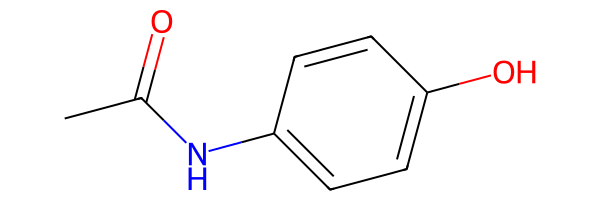

In [20]:
result.draw(width=600)

As expected, `ugropy` fails to obtain the fragmentation of the molecule because 
the `NH` group is not covered by any available fragment, leaving free atoms 
unaccounted for.

First, let's leverage our knowledge from the previous section to retrieve the 
complete data from the UNIFAC model's attributes.

First, the SMARTS DataFrame:

In [21]:
subgroups = unifac.subgroups.copy()

subgroups

,smarts,molecular_weight
group,,
CH3,[CX4H3],15.03500
CH2,[CX4H2],14.02700
CH,[CX4H],13.01900
C,[CX4H0],12.01100
CH2=CH,[CH2]=[CH],27.04600
...,...,...
NCO,[NX2H0]=[CX2H0]=[OX1H0],42.01700
(CH2)2SU,[CH2]S(=O)(=O)[CH2],92.11620
CH2CHSU,[CH2]S(=O)(=O)[CH],91.10840


Since UNIFAC is a `GibbsModel`, we also need to retrieve the fragments
information to instantiate a new model:

In [22]:
subgroups_info = unifac.subgroups_info.copy()

subgroups_info

,subgroup_number,main_group,R,Q
group,,,,
CH3,1,1,0.9011,0.848
CH2,2,1,0.6744,0.540
CH,3,1,0.4469,0.228
C,4,1,0.2195,0.000
CH2=CH,5,2,1.3454,1.176
...,...,...,...,...
NCO,109,51,1.0567,0.732
(CH2)2SU,118,55,2.6869,2.120
CH2CHSU,119,55,2.4595,1.808


Now, lets modify the SMARTS pattern of the `ACNH2` fragment to match both
`ACNH2` and `ACNH` structures and instantiate a new model with the modified
SMARTS pattern:

In [23]:
from ugropy import GibbsModel

# Change directly the SMARTS column for the ACNH2 fragment
# now the aromatic carbon could be bonded to either NH2 or NH.
subgroups.loc["ACNH2", "smarts"] = "[cH0][NH2,NH]"

new_unifac = GibbsModel(
    subgroups=subgroups,
    subgroups_info=subgroups_info,
    calculate_r_q=True
)

Now, lets try to fragment the same molecule with our modified UNIFAC model:

In [24]:
result = new_unifac.get_groups("CC(=O)NC1=CC=C(O)C=C1", "smiles")

print(result.subgroups)

{'ACH': 4, 'ACOH': 1, 'CH3CO': 1, 'ACNH2': 1}


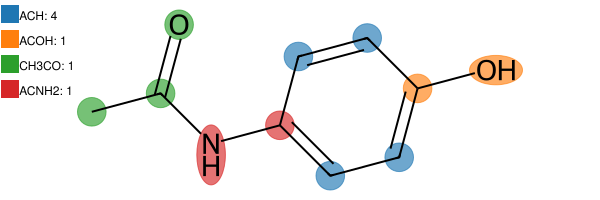

In [25]:
result.draw(width=600)

Success! Now, the `ACNH` structure present in the molecule is successfully
detected under the `ACNH2` fragment definition.

### Understanding which fragment is not being detected

There is an additional technique available for all models that helps you 
determine whether a specific fragment is being successfully detected within a 
molecule. This short section serves as a diagnostic bridge between modifying an 
existing model and creating your own from scratch.

To explore this, we can use the `instantiate_mol_object` function from
`ugropy`. This function processes any of the molecular identifiers supported by
the `get_groups` method to return an RDKit Mol object.

Additionally, all `FragmentationModel` instances implement the
`detect_fragments` method. While this method is typically executed internally
during the `get_groups` call, we can call it explicitly to inspect which
fragments are captured during the initial direct detection step of the
algorithm.

Let's check the `instantiate_mol_object` docstring:

In [30]:
from ugropy import instantiate_mol_object

help(instantiate_mol_object)

Help on function instantiate_mol_object in module ugropy.core.get_rdkit_object:

instantiate_mol_object(identifier: Union[str, rdkit.Chem.rdchem.Mol], identifier_type: str = 'name') -> rdkit.Chem.rdchem.Mol
    Instantiate a RDKit Mol object from molecule's name, SMILES or mol.

    In case that the input its already a RDKit Mol object, the function will
    return the input object.

    Parameters
    ----------
    identifier : str or rdkit.Chem.rdchem.Mol
        Identifier of a molecule (name, SMILES or rdkit.Chem.rdchem.Mol).
        Example: hexane or CCCCCC for name or SMILES respectively.
    identifier_type : str, optional
        Use 'name' to search a molecule by name, 'smiles' to provide the
        molecule SMILES representation or 'mol' to provide a
        rdkit.Chem.rdchem.Mol object, by default "name".

    Returns
    -------
    rdkit.Chem.rdchem.Mol
        RDKit Mol object.



Now, let's test this with the molecule from the previous example, comparing the
original UNIFAC model against our modified version (`new_unifac`). First, using
the original model:

In [31]:
mol = instantiate_mol_object("CC(=O)NC1=CC=C(O)C=C1", "smiles")

unifac.detect_fragments(mol)

{'CH3_0': (0,),
 'ACH_0': (5,),
 'ACH_1': (6,),
 'ACH_2': (9,),
 'ACH_3': (10,),
 'AC_0': (4,),
 'AC_1': (7,),
 'OH_0': (8,),
 'ACOH_0': (7, 8),
 'CH3CO_0': (0, 1, 2)}

As you can observe, the `ACNH2` fragment is missing from the detections. Now, 
let's run the same check using our modified UNIFAC instance:

In [32]:
new_unifac.detect_fragments(mol)

{'CH3_0': (0,),
 'ACH_0': (5,),
 'ACH_1': (6,),
 'ACH_2': (9,),
 'ACH_3': (10,),
 'AC_0': (4,),
 'AC_1': (7,),
 'OH_0': (8,),
 'ACOH_0': (7, 8),
 'CH3CO_0': (0, 1, 2),
 'ACNH2_0': (4, 3)}

Now, the `ACNH2` fragment is successfully detected. 

The numbers inside each tuple represent the atom indices occupied by that specific 
detection. The numeric suffix of each fragment key indicates the distinct occurrences 
of that fragment type. For example:

- ACH_**0**: (5,)

- ACH_**1**: (6,)

- ACH_**2**: (9,)

- ACH_**3**: (10,)

This indicates that our molecule contains four total `ACH` fragments, each 
occupying different atoms (note that implicit hydrogens are never counted as independent 
atoms in the RDKit library).

### User defined fragmentation models

This section will be brief, as it involves advanced Python concepts that are 
beyond the scope of this tutorial and will not be explained from scratch.

If you want to create your own specialized category of `FragmentationModel`, 
you need to master two key elements. First, you must learn the SMARTS notation 
to define your fragments (covered as a brief introduction in the next section). 
Second, you need to understand how to extend the behavior of the base 
`FragmentationModel` and `FragmentationResult` classes via inheritance:

```python
from ugropy import FragmentationModel, FragmentationResult


class MyFragModel(FragmentationModel):
    ...


class MyFragModelResult(FragmentationResult):
    ...
```

Maybe you want to create a model that, after detecting the fragments, performs
additional operations with them, such as property estimations. The best
approach at this point is to check the `ugropy` source code and learn from it
directly (it is not that much code, I promise!).

First, explore the two base classes to understand their core architecture:

- [FragmentationModel](https://github.com/ipqa-research/ugropy/blob/main/ugropy/core/frag_classes/base/fragmentation_model.py)
- [FragmentationResult](https://github.com/ipqa-research/ugropy/blob/main/ugropy/core/frag_classes/base/fragmentation_result.py)

Then, you can look at a straightforward extension of the base class, the
`GibbsModel` and its corresponding result class:

- [GibbsModel](https://github.com/ipqa-research/ugropy/blob/main/ugropy/core/frag_classes/gibbs_model/gibbs_model.py)
- [GibbsResult](https://github.com/ipqa-research/ugropy/blob/main/ugropy/core/frag_classes/gibbs_model/gibbs_result.py)

In the `GibbsModel` definition, you will see how the `__init__` method is
**overridden** to customize its docstring and incorporate new parameters.
Moreover, additional validation filters are implemented in this subclass (while
those already present in `FragmentationModel` are automatically inherited). In
`GibbsResult`, you can check how the calculation of the $R$ and $Q$ values is
triggered once the fragmentation result is received.

Finally, you can inspect a more complex implementation, specifically its result
class, `JobackResult`. While the underlying logic remains the same, it serves
as a more advanced example that demonstrates how `ugropy` internally integrates
the `Pint` library for unit management:

- [JobackFragmentationResult](https://github.com/ipqa-research/ugropy/blob/main/ugropy/core/frag_classes/joback/joback_result.py)

Every class definition is available in the repository, providing a clear
blueprint to build your own custom models.

Finally, there is an optional method in the `FragmentationModel` base class 
that we haven't discussed yet: `mol_preprocess`.

This method is executed internally during the `get_groups` call. The algorithm
first creates the RDKit Mol object via `instantiate_mol_object` and then passes
that object directly to `mol_preprocess`. By default, this method returns the
molecule unchanged. However, if you inherit from the base class, you can
**override** it to leverage RDKit's full capabilities to modify the nature of
the molecule before any fragment detection takes place. For instance, you could
force specific rings to be considered aromatic (or non-aromatic), sanitize
functional groups, or perform advanced structural manipulations tailored to
your needs.

That being said, for the majority of use cases, you won't need to touch this
method. Most fragmentation challenges can be resolved simply by defining your
SMARTS patterns correctly!

### SMARTS tutorial

This is the final piece of the puzzle you need to master to define your own 
fragmentation models. Before diving in, a quick word of caution: this is not a 
trivial task. It requires not only a solid grasp of the SMARTS syntax but also 
an understanding of how fragment definitions can be deeply dependent on the 
thermodynamic model itself (we will explore some examples of this later).

This brief tutorial is based on the official Daylight documentation, where you 
can find all the fundamental directives of the SMARTS syntax:

- [Daylight SMARTS Theory](https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html)

Additionally, RDKit supports certain extended SMARTS features, such as Chemaxon
extended SMARTS link nodes, which can be incredibly useful for complex
macro-structures:

- [Chemaxon Extended SMARTS](https://docs.chemaxon.com/latest/formats_chemaxon-extended-smiles-and-smarts-cxsmiles-and-cxsmarts.html)

The first golden rule is: **you must strictly follow the SMARTS syntax that
RDKit understands**. Furthermore, you can inspect the production-ready SMARTS
definitions for all built-in models directly in the `ugropy` repository. While
perhaps not exhaustive, they serve as a learning resource:

- [`ugropy` Groups CSV Repository](https://github.com/ipqa-research/ugropy/tree/main/ugropy/groupscsv)

Ultimately, the performance of your custom model will be strictly dictated by
how precisely you define your fragments, defining "performance" here as: the
model detects the exact fragments I want it to detect for this molecule. For
that, testing is crucial (refer to the test book to find some examples of
molecules with their SMILES representations).

#### The basics

In SMARTS (as in SMILES notation), we define chemical structures using specific 
structural or logical patterns. These structures are read and evaluated from 
left to right. For example, consider the n-hexane molecule:

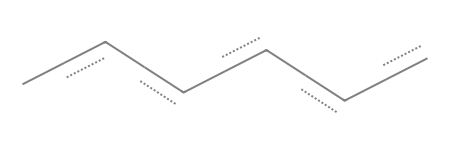

In [35]:
from rdkit import Chem

smt = Chem.MolFromSmarts("CCCCCC")

smt

Here, we are defining six aliphatic carbons "bonded" one after the other. I
emphasize "bonded" because we are not explicitly specifying the type of bond
yet. Let's explicitly define that these connections are single bonds:

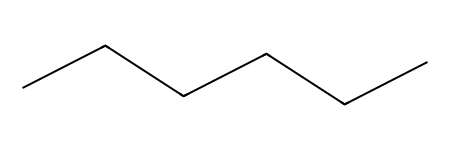

In [36]:
smt = Chem.MolFromSmarts("C-C-C-C-C-C")

smt

See how the drawing changes? Now we have explicitly defined six aliphatic
carbons connected by single bonds.

Let's add a double bond in the middle:

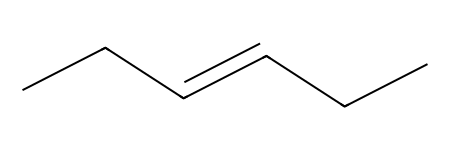

In [37]:
smt = Chem.MolFromSmarts("C-C-C=C-C-C")

smt

Now, a double bond is specified between positions 3 and 4. As a side note,
implicit hydrohens are automatically accounted for in this simplified notation
until the standard valence of the atom is satisfied.

This approach feels very similar to writing standard SMILES. However, when
defining robust SMARTS patterns for group contribution models, we usually
need to enforce the exact connectivity of an atom and specify precisely how
many hydrogens are bonded to it. Let's completely and explicitly define the
n-hexane molecule using strict SMARTS syntax:

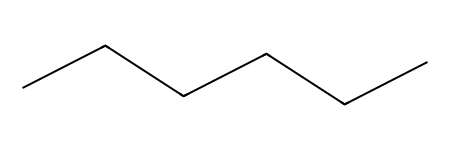

In [38]:
smt = Chem.MolFromSmarts("[CX4H3]-[CX4H2]-[CX4H2]-[CX4H2]-[CX4H2]-[CX4H3]")

smt

Nothing seems to change in the visual representation, but we have introduced a
lot of new notation. Let's break it down step by step. 

First, the brackets: in SMARTS notation, brackets `[]` indicate that an atom is
being defined by specific logical properties or constraints. The structure
`[CX4H3]` is telling the engine: *"This is an aliphatic carbon (`C`) bonded to
four total atoms (`X4`), and exactly three of those four connections are
hydrogens (`H3`, which sets the explicit hydrogen count)."*

Similarly, with `[CX4H2]`, we are specifying an aliphatic carbon bonded to four
total atoms, two of which must be hydrogens.

Therefore, when we write `[CX4H3]-[CX4H2]`, we are saying—and pardon the
redundancy: *"An aliphatic carbon with a total connectivity of 4 and three
hydrogens is bonded via a single covalent bond to an aliphatic carbon with a
total connectivity of 4 and two hydrogens."*

Let's define this small substructure (`[CX4H3]-[CX4H2]`) and search for it
within the n-hexane molecule. Naturally, we should find exactly two
occurrences:


In [41]:
hexane = Chem.MolFromSmiles("CCCCCC") # n-hexane

smt = Chem.MolFromSmarts("[CX4H3]-[CX4H2]")

matches = hexane.GetSubstructMatches(smt)

print("Matches:", matches)
print("Number of matches:", len(matches))

Matches: ((0, 1), (5, 4))
Number of matches: 2


As expected, we found two of these substructures at atom indices (0, 1) and (5,
4). 

At this point, an attentive reader might think:

*"Well, if I am already enforcing the connectivity of the carbons (`X4`) and
the exact number of hydrogens, explicitly defining the single bond in this
particular case seems redundant."*

And you would be absolutely right! In logical terms, these two definitions are
completely equivalent:

* `[CX4H3]-[CX4H2]`
* `[CX4H3][CX4H2]`

But be careful: if you don't restrict the total connectivity of an atom, it can
lead to unexpected false positives. Let's analyze the pattern `[CH2]`. Here, we
are enforcing the hydrogen count but leaving the total connectivity open. It
works perfectly fine for n-hexane:

In [45]:
smt = Chem.MolFromSmarts("[CH2]")

hexane = Chem.MolFromSmiles("CCCCCC") # n-hexane

matches = hexane.GetSubstructMatches(smt)

matches

((1,), (2,), (3,), (4,))

However, let's see what happens when we test this exact same pattern against
the propene molecule:

((0,),)


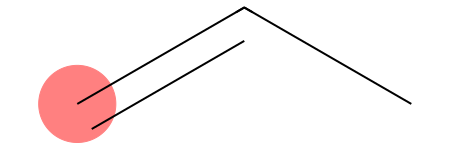

In [46]:
propene = Chem.MolFromSmiles("C=CC") # propene

smt = Chem.MolFromSmarts("[CH2]")

matches = propene.GetSubstructMatches(smt)

print(matches)

propene

We found a detection! And of course we did: the `[CH2]` pattern simply asks for
*any aliphatic carbon with exactly two hydrogens*. In propene, the terminal
alkene carbon (position 2 or 0 depending on RDKit indexing) satisfies this
exact condition. 

If your thermodynamic model needs to distinguish between an unreactive
aliphatic alkane group and an olefinic group, a generic pattern like `[CH2]`
will ruin your fragmentation parameters. This is precisely where the **SMARTS
craftsmanship** comes into play. 

Let's design two distinct patterns to cleanly separate both cases:

In [48]:
# Alkane CH2 (sp3 carbon bonded to 4 atoms total)
alkane_ch2 = Chem.MolFromSmarts("[CX4H2]")

# Alkene CH2 (sp2 carbon bonded to 3 atoms total)
alkene_ch2 = Chem.MolFromSmarts("[CX3H2]") 

print("Hexane alkane CH2 matches:", hexane.GetSubstructMatches(alkane_ch2))
print("Hexane alkene CH2 matches:", hexane.GetSubstructMatches(alkene_ch2))

print("Propene alkane CH2 matches:", propene.GetSubstructMatches(alkane_ch2))
print("Propene alkene CH2 matches:", propene.GetSubstructMatches(alkene_ch2))

Hexane alkane CH2 matches: ((1,), (2,), (3,), (4,))
Hexane alkene CH2 matches: ()
Propene alkane CH2 matches: ()
Propene alkene CH2 matches: ((0,),)


While evaluating structures from left to right works perfectly for linear
chains, chemistry is full of branched architectures. Using purely linear logic
makes it impossible to define non-linear molecules. To solve this, SMARTS
introduces **parentheses**.

Consider the following pattern:

`[CX4H3][CX4H2]([OH])[CX4H3]`

In chemical terms, we are defining:

* `[CX4H3]`: An aliphatic carbon with four connections and three hydrogens ($\text{-CH}_3$).
* `[CX4H2]`: An aliphatic carbon with four connections and two hydrogens ($\text{-CH}_2\text{-}$ before branching).
* `[OH]`: A hydroxyl group.

The structure can be read as follows: We have a $\text{-CH}_3$ group bonded to
a carbon, which is simultaneously bonded to both an $\text{-OH}$ group and
another $\text{-CH}_3$ group. Let's build and render this structure in RDKit:

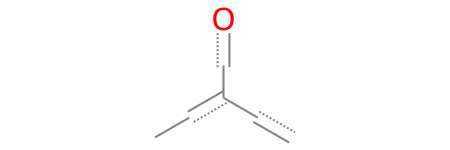

In [52]:
smt = Chem.MolFromSmarts('[CX4H3][CX4H2]([OH])[CX4H3]')

smt

The golden rule for branching is: **any atom or chain written inside
parentheses is always bonded to the atom immediately to its left** (in this
case, the `[CX4H2]` carbon).

If we want to explicitly specify every single bond in this branched structure,
notice carefully where the bond dashes `-` must be placed:

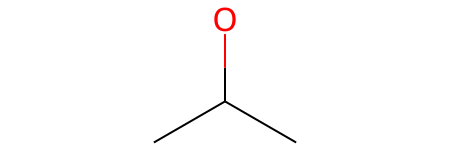

In [53]:
smt = Chem.MolFromSmarts('[CX4H3]-[CX4H2](-[OH])-[CX4H3]')

smt

Finally, for `The basics`, we have rings. This is not very interesting but is
helfphul for some fragments that are directly aromatic or aliphatic ring. How we
define a ring? We use numbers, we señalizes two atoms with a number and those
are going to be bonding like breaking the left to right rule. For example
a cyclohexene ring would be:

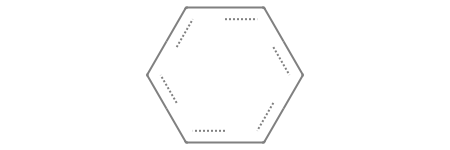

In [54]:
# Check the first and the last [CX4H2] have a 1, they are going to be bonded
smt = Chem.MolFromSmarts("[CX4H2]1[CX4H2][CX4H2][CX4H2][CX4H2][CX4H2]1")

smt

#### Rings and aromaticity

What happens when we want to define a fragment that only can be detected if it
is present on an aliphatic ring? Well, here comes into play the SMARTS logic
statemes:

- `&`: "and" high precedence
- `;`: "and" low precedence
- `,`: "or" low precedence

The precedence refers at the same concept as in the programming language, are
logical operators that resolves in different orders. High precedence operators
solves first, there is no parenthesis shenanigans en SMARTS syntax sin
parenthesis means things